In [1]:
%matplotlib inline

import numpy
from matplotlib import pyplot

pyplot.rc('text', usetex=True)
pyplot.rc('figure', figsize=[12, 8], dpi=144)

def scatter(x, y, z, optical_depth):
    scatter_angle_azimuthal = 2 * numpy.pi * numpy.random.random()
    scatter_angle_polar = numpy.pi * (numpy.random.random() - 0.5)

    xy_projection = optical_depth * numpy.sin(scatter_angle_polar)

    return (
        x + xy_projection * numpy.cos(scatter_angle_azimuthal),
        y + xy_projection * numpy.sin(scatter_angle_azimuthal),
        z + optical_depth * numpy.cos(scatter_angle_polar)
    )

In [2]:
def simulate(x, y, z, optical_depth, scatter_probability, radius):
    path = [(x, y, z)]
    time = 0
    while True:
        time += 1
        if numpy.random.random() < scatter_probability:
            x, y, z = scatter(x, y, z, optical_depth)
            path.append((x, y, z))
            if (x ** 2 + y ** 2 + z ** 2) > radius:
                return 'escaped', time, path
        else:
            return 'absorbed', time, path

In [3]:
from collections import defaultdict

distributions = defaultdict(list)
for i in range(1000):
    for j in range(1000):
        event, time, path = simulate(0., 0., 0., 1., 0.5, 10.)
        distributions[event].append(time)

(array([4.99403e+05, 2.50430e+05, 1.25066e+05, 6.26900e+04, 0.00000e+00,
        1.96780e+04, 3.74900e+03, 4.91000e+02, 5.30000e+01, 7.00000e+00]),
 array([1. , 1.8, 2.6, 3.4, 4.2, 5. , 5.8, 6.6, 7.4, 8.2, 9. ]),
 <BarContainer object of 10 artists>)

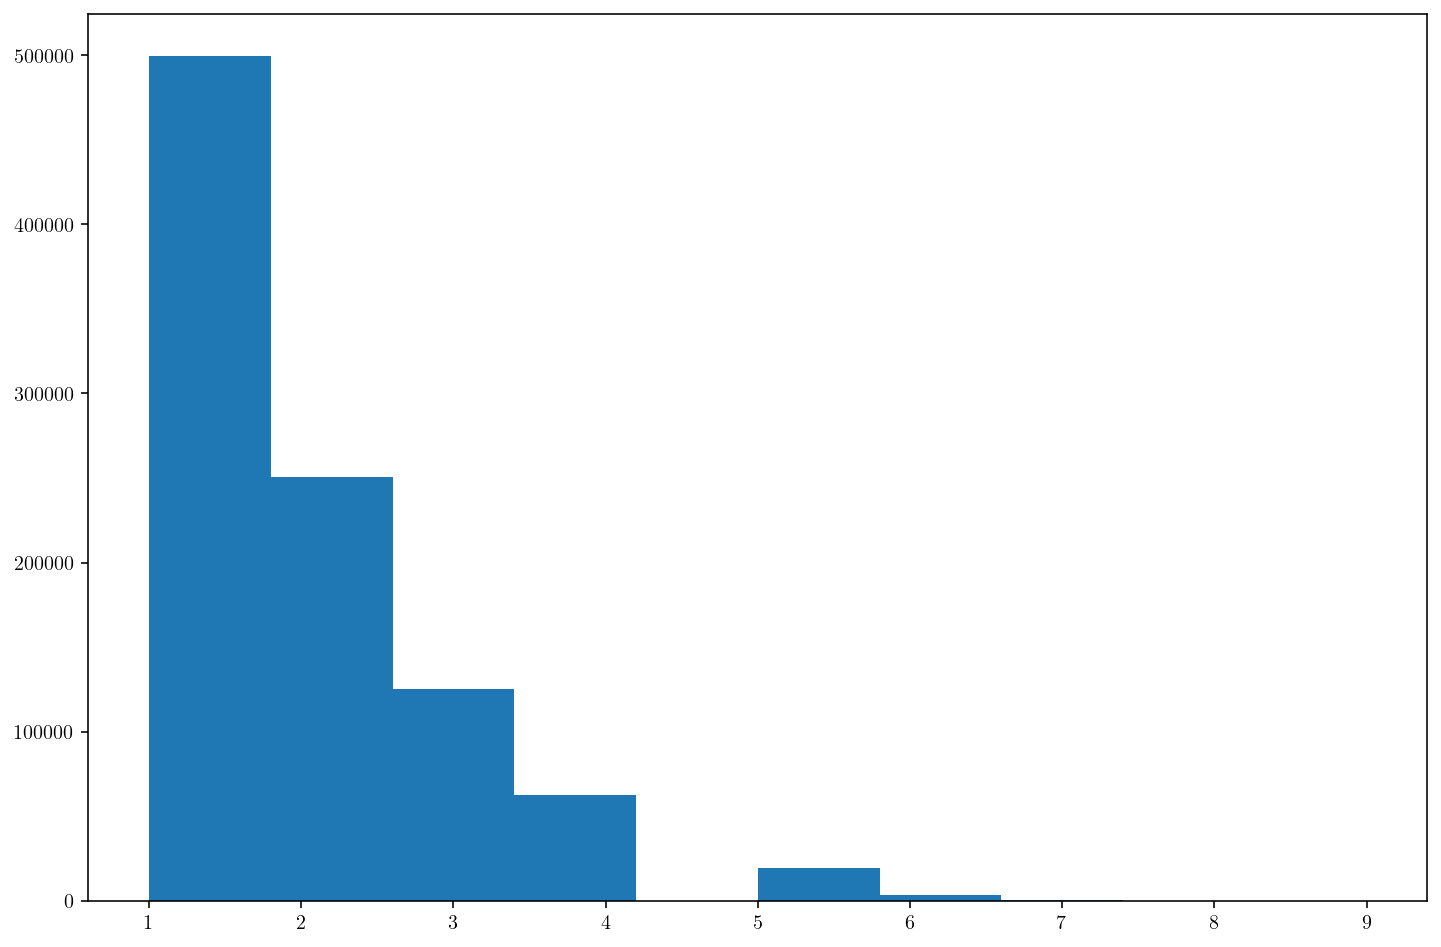

In [4]:
pyplot.hist(distributions['absorbed'], 10)

(array([2.3162e+04, 1.2090e+04, 0.0000e+00, 2.7080e+03, 0.0000e+00,
        4.2000e+02, 4.9000e+01, 0.0000e+00, 3.0000e+00, 1.0000e+00]),
 array([ 4. ,  4.6,  5.2,  5.8,  6.4,  7. ,  7.6,  8.2,  8.8,  9.4, 10. ]),
 <BarContainer object of 10 artists>)

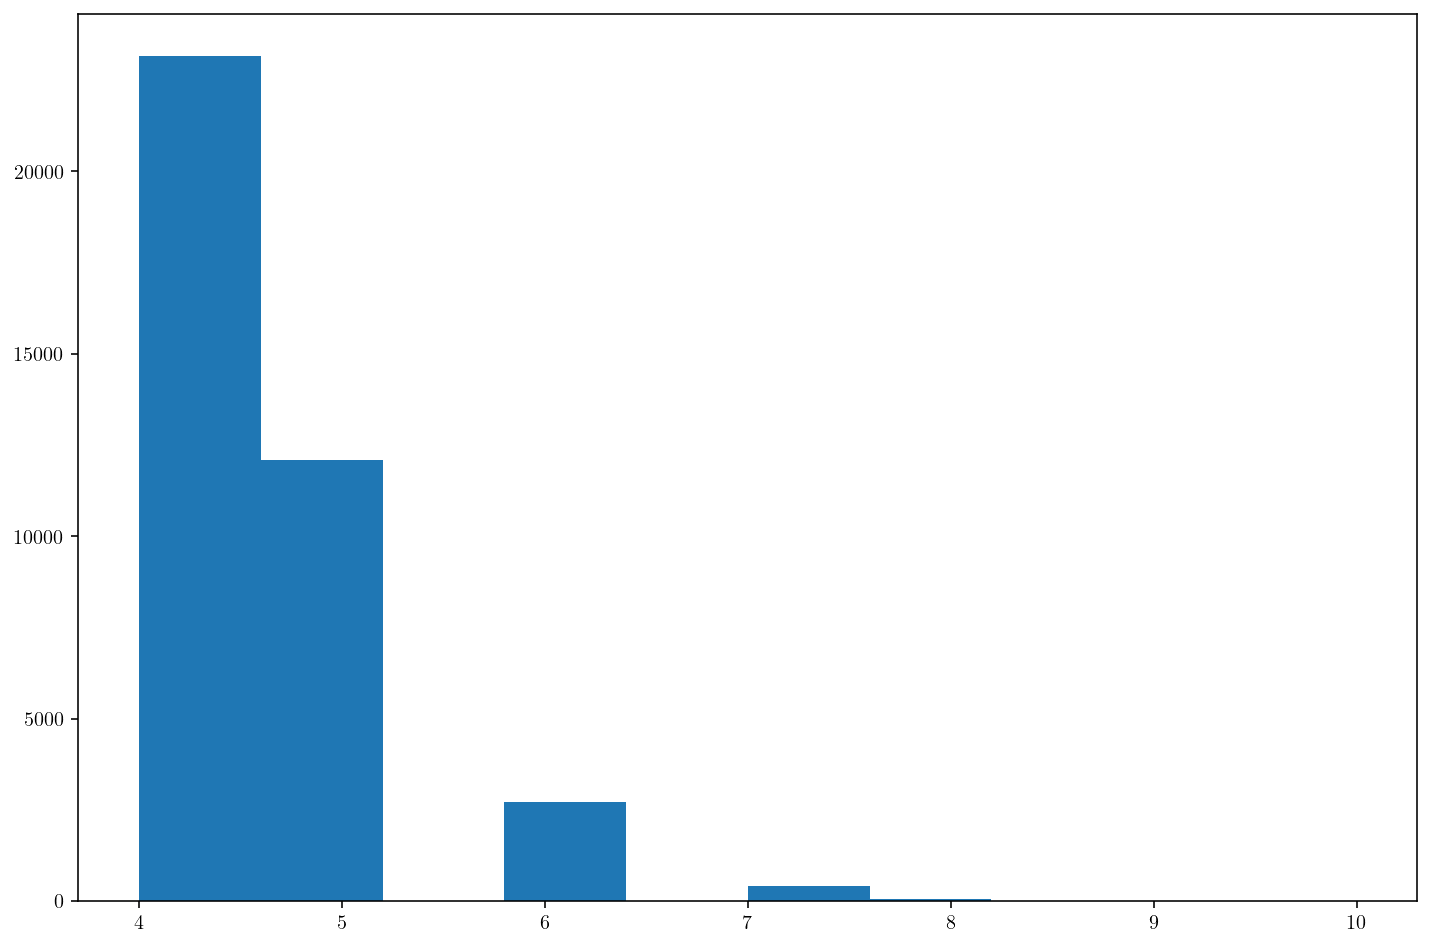

In [5]:
pyplot.hist(distributions['escaped'], 10)

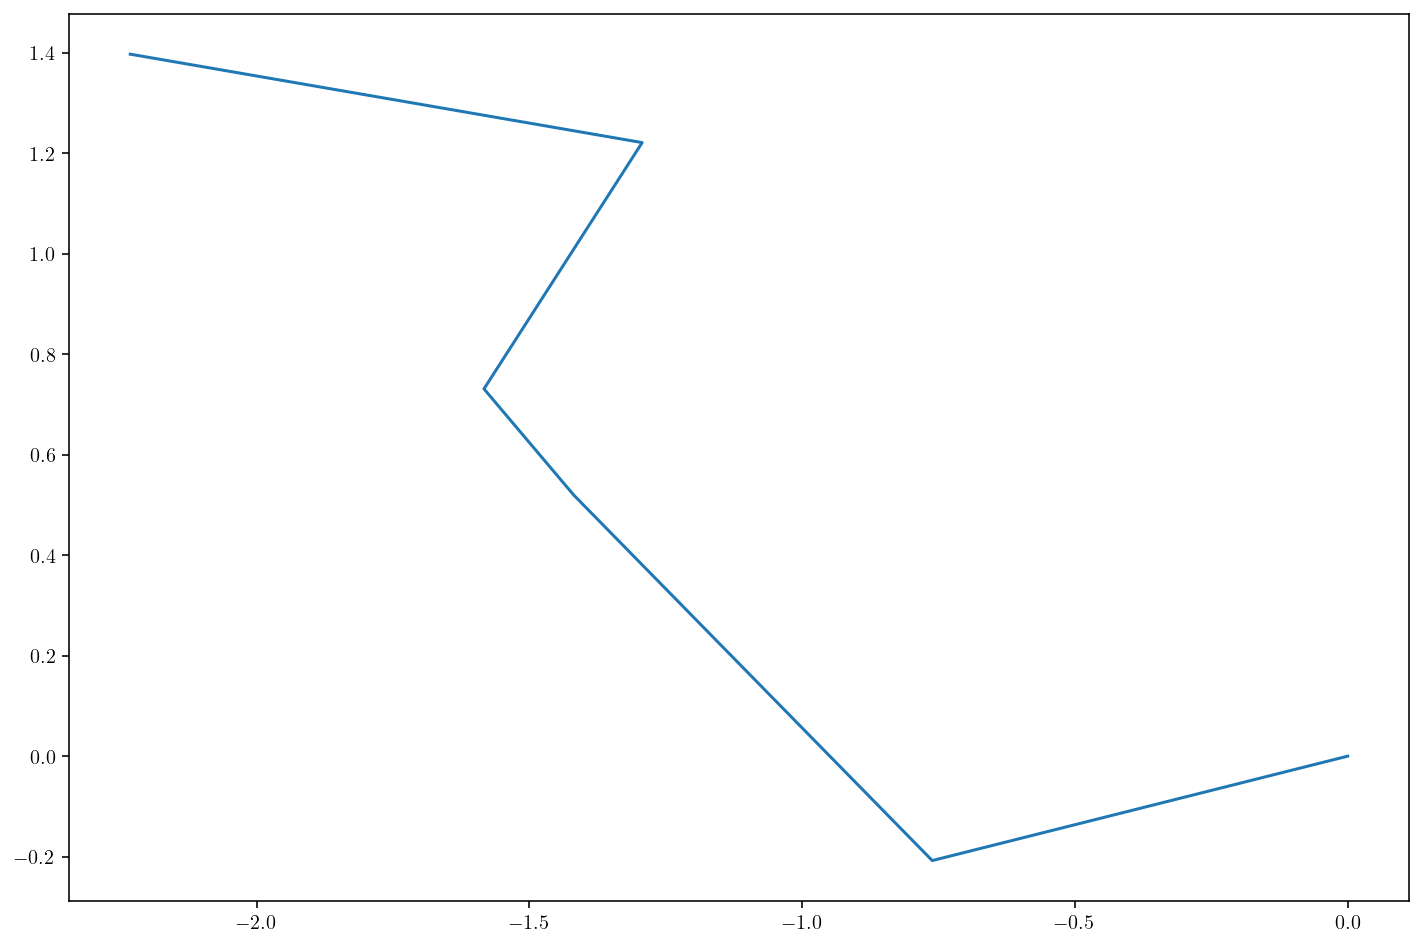

In [6]:
while True:
    event, time, path = simulate(0., 0., 0., 1., 0.5, 10.)
    if event == 'escaped':
        x, y, z = zip(*path)
        break

pyplot.plot(x, y)